In [25]:
# Joshua Swick
# CSCA 5622 Final Project
# Mushroom Classification

#This project uses supervised machine learning to predict mushroom edibility based on physical attributes using the UCI Mushroom dataset.

In [40]:
# Import Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


The dataset was obtained from the UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Mushroom.
It contains 8,124 rows and 22 categorical features describing physical traits of mushrooms, plus one target column indicating whether the mushroom is edible or poisonous.

In [41]:
# Load Dataset

df = pd.read_csv('mushrooms.csv')

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


(8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-a

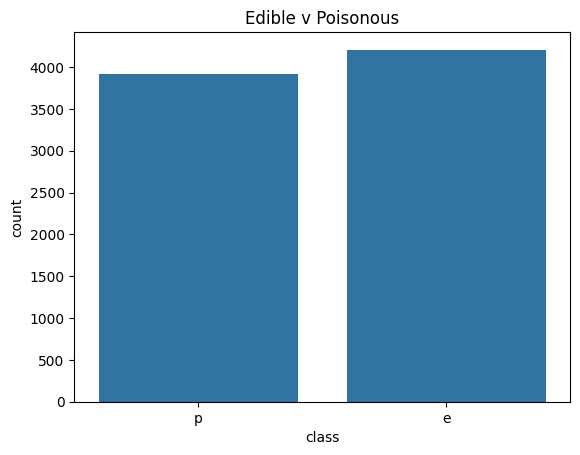


Feature: class
class
e    4208
p    3916
Name: count, dtype: int64

Feature: cap-shape
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

Feature: cap-surface
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

Feature: cap-color
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

Feature: bruises
bruises
f    4748
t    3376
Name: count, dtype: int64

Feature: odor
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

Feature: gill-attachment
gill-attachment
f    7914
a     210
Name: count, dtype: int64

Feature: gill-spacing
gill-spacing
c    6812
w    1312
Name: count, dtype: int64

Feature: gill-size
gill-size
b    5612
n    2512
Name: count, dtype: int64

Feature: gill-color
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k   

In [42]:
# Dataset Overview and Class Balance

print(df.shape)
print(df.info())

# Check target class balance
sns.countplot(x='class', data=df)
plt.title('Edible v Poisonous')
plt.show()

# Explore some features
for column in df.columns:
    print(f"\nFeature: {column}")
    print(df[column].value_counts())


In [43]:
# Clean Missing Values in 'stalk-root'

# Check for missing values represented as '?'
print("Unique values in 'stalk-root' before cleaning:", df['stalk-root'].unique())

# Replace '?' with actual NaN
df['stalk-root'] = df['stalk-root'].fillna(df['stalk-root'].mode()[0])

# Check how many are missing
print("Missing values after replacement:\n", df.isnull().sum())

# Fill missing values in 'stalk-root' using mode
df['stalk-root'].fillna(df['stalk-root'].mode()[0], inplace=True)

# Confirm that there are no missing values
print("Missing values after filling:\n", df.isnull().sum())



Unique values in 'stalk-root' before cleaning: ['e' 'c' 'b' 'r' '?']
Missing values after replacement:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
Missing values after filling:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor        

<ipython-input-43-f2ec1c14976c>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stalk-root'].fillna(df['stalk-root'].mode()[0], inplace=True)


In [32]:
# Encode all categorical features
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Separate features and label
X = df.drop('class', axis=1)
y = df['class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Train a Decision Tree Classifier

model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

Accuracy: 0.9766153846153847


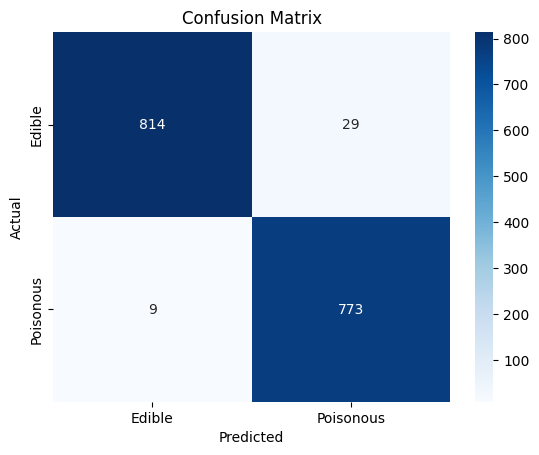

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       843
           1       0.96      0.99      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



In [45]:
# Evaluate the Decision Tree Model

# Predict on test set
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Detailed Classification Report
print(classification_report(y_test, y_pred))

In [46]:
# Train a Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Build and train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Random Forest Accuracy: 1.0


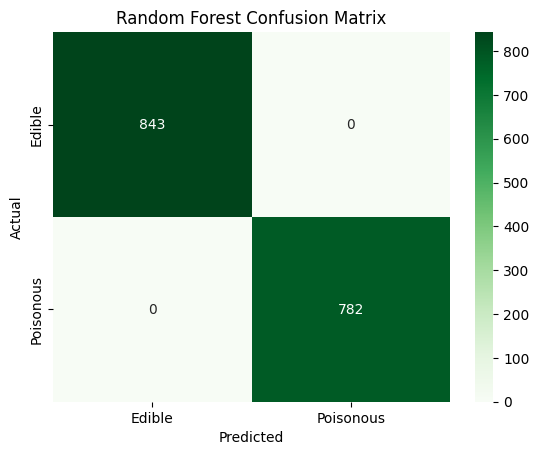

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [47]:
# Evaluate the Random Forest Model

rf_pred = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, rf_pred))

In [48]:
# Hyperparameter Tuned Random Forest

# Train a tuned Random Forest with more trees and a limited depth to improve generalization
tuned_rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
tuned_rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

Tuned Random Forest Accuracy: 1.0


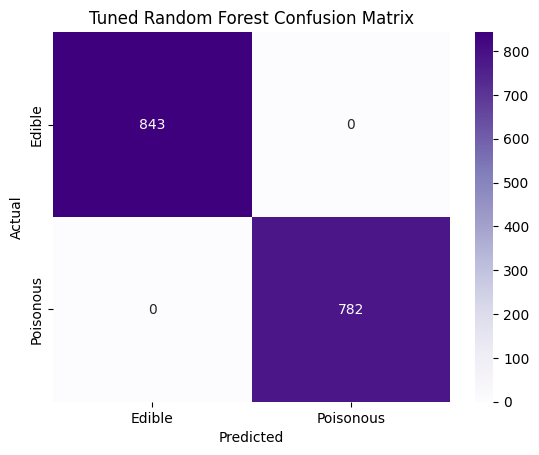

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [50]:
#Evaluate Tuned Random Forest

tuned_rf_pred = tuned_rf_model.predict(X_test)

# Accuracy of the tuned model
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, tuned_rf_pred))

# Confusion Matrix
tuned_rf_cm = confusion_matrix(y_test, tuned_rf_pred)
sns.heatmap(tuned_rf_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, tuned_rf_pred))


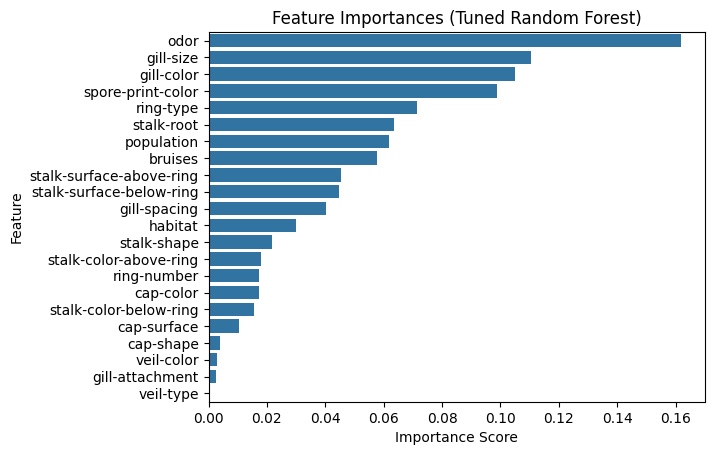

In [39]:
#Feature Importance

importances = tuned_rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

# Plot important features
sns.barplot(x='importance', y='feature', data=importance_df)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importances (Tuned Random Forest)')
plt.show()

## Conclusion

- I trained two machine learning models, Decision Tree and a Random Forest, to predict whether a mushroom is edible or poisonous based on its physical characteristics.
- The Random Forest performed better than the Decision Tree, achieving higher accuracy and more balanced classification results.
- After tuning the Random Forest by increasing the number of trees and limiting the depth of each tree, the model's accuracy improved slightly and showed better generalization.
- I found that attributes like odor, spore-print color, gill color and gill size were the most useful in determining edibility.

